
# Introduction
Science fiction is a genre with roots and themes spanning back to the second century. However, the genre came to prominence in the mid-1800s, and has since only seen growth in popularity, with TV shows like Star Trek and Star Wars booming only a century later and shaping much of pop culture today. For this assignment, I will investigate classic, foundational works of science fiction from the early to mid 1800s.

### My Texts
*Frankenstein* by Mary Shelley (1818)

*The Last Man* by Mary Shelley (1826)

*The Mummy!* by Jane Loudon (1827)

### My Questions

>To what extent do Frankenstein and The Last Man exhibit similar linguistic patterns, and what differences might reflect their different subjects and narratives?

>Are the linguistic patterns in Mary Shelley's Frankenstein and The Last Man more similar to each other than to another novel from the same period?

### My Problems

* What metrics will make the most sense comparing two works of one author? 
* Will that differ to the best way of comparing those works to one work of a different author?
* How to determine meaningful *differences* between two works in a quantifiable way?

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pylab
import requests, re
import operator
import nltk
from bs4 import BeautifulSoup
from collections import Counter
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bslessma\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [6]:
import string

stop_words = nltk.corpus.stopwords.words('english') + [
 'ut', '\'re','.', ',', '--', '\'s', '?', ')', '(', ':', '\'',
 '\"', '-', '}', '{', '&', '|', u'\u2014' ]

def clean_word(wd):
    wd = wd.lower()
    wd = wd.strip(string.punctuation)
    return wd

# get rid of all the stuff above and below the book
def extract_book(text):
    start_marker = "*** START OF THE PROJECT GUTENBERG EBOOK"
    end_marker = "*** END OF THE PROJECT GUTENBERG EBOOK"

    start = text.find(start_marker)
    end = text.find(end_marker)

    if start != -1 and end != -1:
        return text[start + len(start_marker):end]

    return text

# better for when I need to do the bigrams
def clean_text(text):
    text = extract_book(text)

    words = []

    for wd in text.split():
        wd = clean_word(wd)

        if wd not in stop_words:
            words.append(wd)

    return words

Frankenstein_txt = requests.get('https://www.gutenberg.org/ebooks/84.txt.utf-8').text
TheLastMan_txt = requests.get('https://www.gutenberg.org/ebooks/18247.txt.utf-8').text
TheMummy_txt = requests.get('https://www.gutenberg.org/ebooks/56426.txt.utf-8').text

Frankenstein_wds = clean_text(Frankenstein_txt)
TheLastMan_wds = clean_text(TheLastMan_txt)
TheMummy_wds = clean_text(TheMummy_txt)

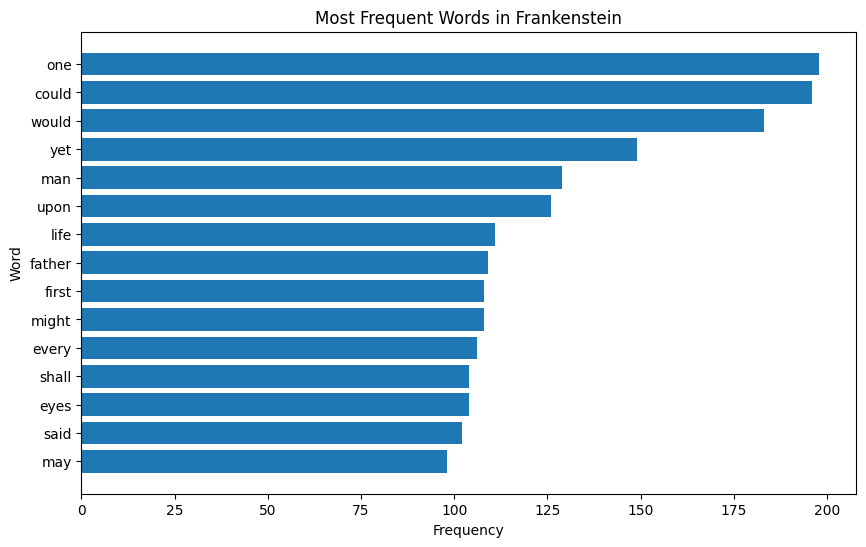

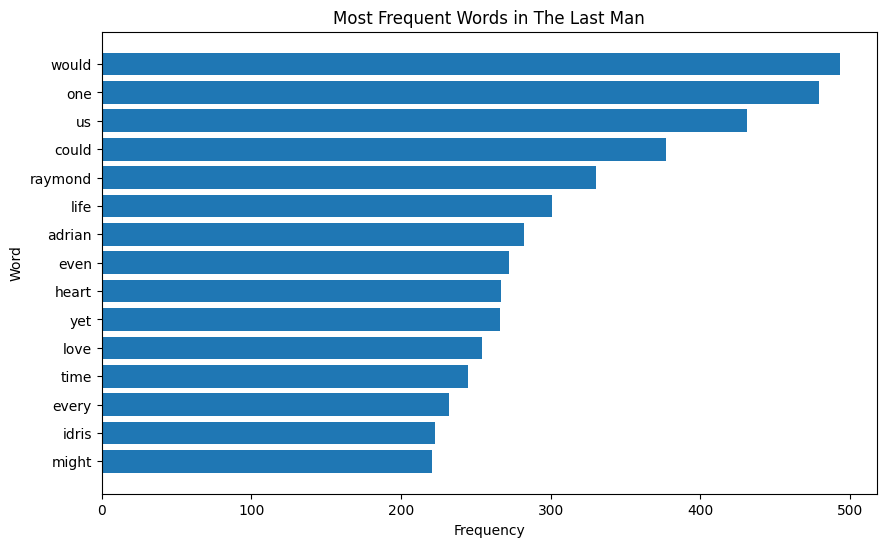

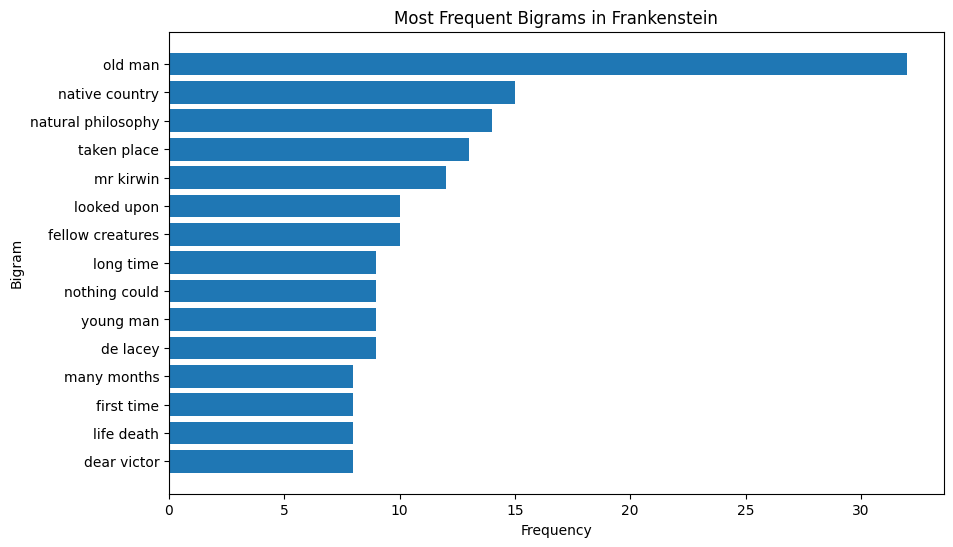

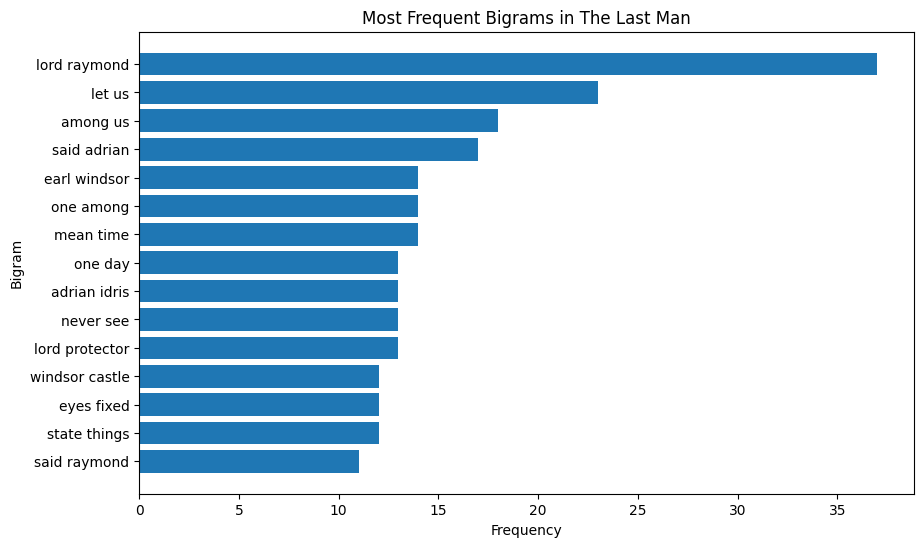

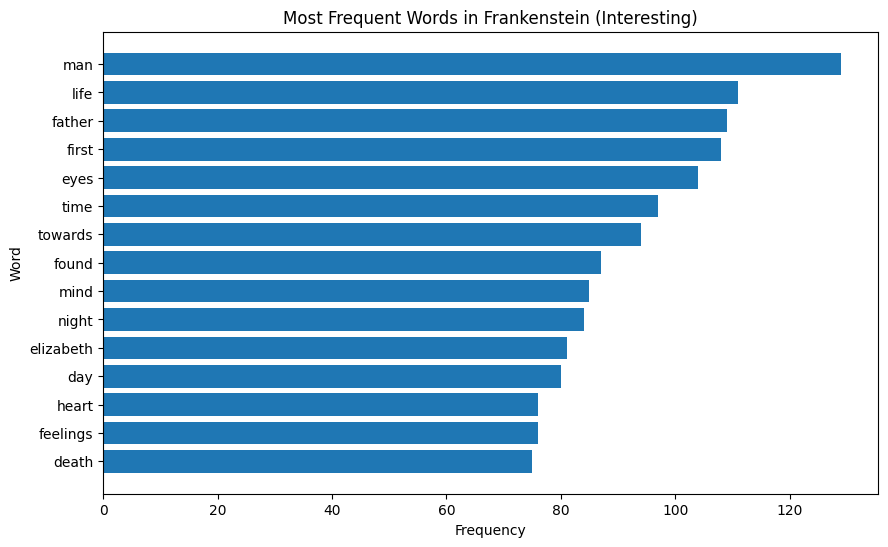

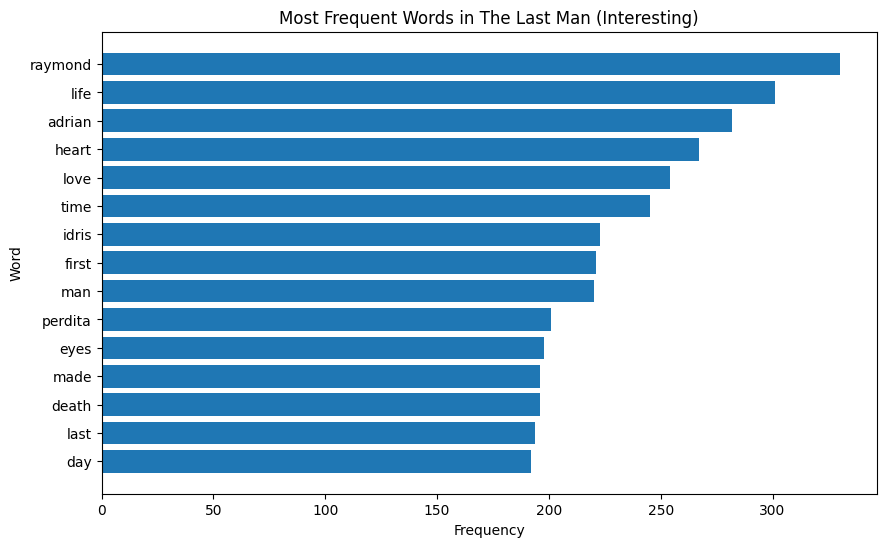

In [7]:
from nltk.util import ngrams

# Raw Freq
Frankenstein_freq = Counter(Frankenstein_wds)
TheLastMan_freq = Counter(TheLastMan_wds)

# Normalized Freq

# Bigrams
Frankenstein_bi = Counter(ngrams(Frankenstein_wds, 2))
TheLastMan_bi = Counter(ngrams(TheLastMan_wds, 2))

# Filtered
uninteresting_wds = ["would", "could", "said", "upon", "yet", "might", "shall", "may", "one", "saw", "even", "felt", "ever", "us", "must", "every"]
Frankenstein_filtered = [
    wd for wd in Frankenstein_wds
    if wd not in uninteresting_wds
]
Frankenstein_filtered_freq = Counter(Frankenstein_filtered)

TheLastMan_filtered = [
    wd for wd in TheLastMan_wds
    if wd not in uninteresting_wds
]
TheLastMan_filtered_freq = Counter(TheLastMan_filtered)


# Most Frequent
words = Frankenstein_freq.most_common(15)

labels = [x[0] for x in words]
values = [x[1] for x in words]

plt.figure(figsize=(10, 6))
plt.barh(labels, values)
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Most Frequent Words in Frankenstein")
plt.gca().invert_yaxis()
plt.show()

words = TheLastMan_freq.most_common(15)

labels = [x[0] for x in words]
values = [x[1] for x in words]

plt.figure(figsize=(10, 6))
plt.barh(labels, values)
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Most Frequent Words in The Last Man")
plt.gca().invert_yaxis()
plt.show()

# Bigrams
bigrams = Frankenstein_bi.most_common(15)

labels = [' '.join(x[0]) for x in bigrams]
values = [x[1] for x in bigrams]

plt.figure(figsize=(10, 6))
plt.barh(labels, values)
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.title("Most Frequent Bigrams in Frankenstein")
plt.gca().invert_yaxis()
plt.show()

bigrams = TheLastMan_bi.most_common(15)

labels = [' '.join(x[0]) for x in bigrams]
values = [x[1] for x in bigrams]

plt.figure(figsize=(10, 6))
plt.barh(labels, values)
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.title("Most Frequent Bigrams in The Last Man")
plt.gca().invert_yaxis()
plt.show()


# Filtered Graph
filtered = Frankenstein_filtered_freq.most_common(15)

labels = [x[0] for x in filtered]
values = [x[1] for x in filtered]

plt.figure(figsize=(10, 6))
plt.barh(labels, values)
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Most Frequent Words in Frankenstein (Interesting)")
plt.gca().invert_yaxis()
plt.show()

filtered = TheLastMan_filtered_freq.most_common(15)

labels = [x[0] for x in filtered]
values = [x[1] for x in filtered]

plt.figure(figsize=(10, 6))
plt.barh(labels, values)
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Most Frequent Words in The Last Man (Interesting)")
plt.gca().invert_yaxis()
plt.show()



# 5 options: bigrams, single word freq, single word freq normal, filtered word freq, filtered word normal
# most freq (raw and filtered) should be listed separate, not as a bar chart but just as a list
# normal should be compared against each other: back to back bar chart for top 30 overall, filtered back to 
#   back for top 20 (excluding names)
# bigrams are more interesting individually, do this like the most freq
# maybe also make a specific filter for action words - said, thought, felt

# if i have time/there's nothing interesting here, we can also look at sentence length and commas?

# Mary Shelley
I'll be looking at *Frankenstein* (1818) and *The Last Man* (1826)

Frankenstein
https://www.gutenberg.org/ebooks/84.txt.utf-8

The Last Man
https://www.gutenberg.org/ebooks/18247.txt.utf-8

# Mary Shelley and Jane Loudon
Next, I'll compare these two works by Mary Shelley against a work by Jane Loudon published around the same time period (1827).

The Mummy! (1827)
https://www.gutenberg.org/ebooks/56426.txt.utf-8

# Analysis
